# Smart Heart Disease Prediction Project

***

### Preet Kulkarni
### Thupakula Pavithra 
### Priyani Naresh K

## **Objective**: To develop a robust predictive model that identifies heart disease in patients by cleaning raw clinical data, establishing a baseline with Logistic Regression, and comparing it against advanced Machine Learning and Deep Learning architectures.

*** 

## **Dataset:**

## Training Dataset (UCI Heart Disease Repository)
This is the primary dataset used to "teach" the model. It is a combined collection of clinical instances from four different geographic locations: Cleveland, Hungary, Switzerland, and Long Beach V.A. Medical Center.

- **Size**: Approximately 900 patient records.

- **Format**: Raw clinical data containing some noise and missing values (indicated by '?').

- **Target Variable (`num`)**: Originally labeled from 0 (Healthy) to 4 (Severe Disease). Our project maps this into a binary classification (0 = Healthy, 1+ = Disease) to align with modern diagnostic goals.

- **Significance**: It provides a diverse range of patient demographics and medical conditions, which helps the neural network learn varied patterns of heart disease.

## Testing Dataset (Out-of-Sample/Kaggle Version)
This dataset acts as the final exam for our models. It is held entirely separate during the training process to provide an unbiased evaluation of the model's performance.

- **Size**: A curated subset of clinical data used for validation.

- **Format**: Generally cleaner than the training set but follows a different labeling convention.

- **Target Variable (`target`)**: Uses a binary format where 1 represents Healthy and 0 represents Disease.

- **Significance**: By testing on this dataset, we can identify if the Neural Network is "overfitting" (memorizing the training data) or if it has truly learned the underlying biological indicators of heart disease.

***

## **Code:**

## 0. Importing required libraries / packages

In [995]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Data Exploration and Cleaning

### Data Acquisition and Initial Inspection

We start by loading the Heart Disease UCI dataset and performing a preliminary check to understand the structure of the data.

In [996]:
# Loading the dataset
df = pd.read_csv("/content/sample_data/heart_disease_uci.csv")

# Displaying the first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Exploratory Data Analysis (EDA)
In this section, we examine the data types, dimensions, non-null values to see if there are any anomalies.

In [997]:
# Exploring the data type of each column
df.info()

# Checking the data shape
print(f"Dataset Shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
Dataset Shape: (920, 16)


### Numeric Iterative Imputation
For initial numeric cleaning, we use the `IterativeImputer`. This estimates missing values by modeling each feature with missing values as a function of others. We start with `trestbps` (resting blood pressure) before moving to other continuous variables.


In [998]:
# Analyze missing values in 'trestbps'
print(f"Percentage of missing values in trestbps: {df['trestbps'].isnull().sum() / len(df) * 100:.2f}%")

# Impute 'trestbps'
imputer1 = IterativeImputer(max_iter=10, random_state=42)
imputer1.fit(df[['trestbps']])
df['trestbps'] = imputer1.transform(df[['trestbps']])

# Apply iterative imputation to other floating-point columns
imputer2 = IterativeImputer(max_iter=10, random_state=42)
cols_to_impute = ['ca', 'oldpeak', 'chol', 'thalch']

for col in cols_to_impute:
    df[col] = imputer2.fit_transform(df[[col]])

print("\nMissing values after continuous imputation (Top 5):")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(5))

Percentage of missing values in trestbps: 6.41%

Missing values after continuous imputation (Top 5):
thal       52.826087
slope      33.586957
fbs         9.782609
exang       5.978261
restecg     0.217391
dtype: float64


### Feature Categorization for ML Imputation
Before building a more complex machine learning imputation pipeline, we need to categorize our columns into Categorical, Boolean, and Numerical types.

In [999]:
# Inspecting missing values in the 'thal' column
print(f"Missing values in thal: {df['thal'].isnull().sum()}")
print(df['thal'].value_counts())

# Identify columns with missing data
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

# Define specific column groups for the imputation logic
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg', 'fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numerical_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

print(f'Categorical Columns: {categorical_cols}')
print(f'Numerical Columns: {numerical_cols}')

Missing values in thal: 486
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64
Categorical Columns: ['thal', 'ca', 'slope', 'exang', 'restecg', 'fbs', 'cp', 'sex', 'num']
Numerical Columns: ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']


### Defining Advanced Imputation Functions
We define two sophisticated functions that use Random Forest models to predict missing values.

- **Classification**: Used for categorical variables.

- **Regression**: Used for continuous variables.

In [1000]:
def impute_categorical_missing_data(passed_col):
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    label_encoder = LabelEncoder()
    for col in X.columns:
        if X[col].dtype in ['object', 'category']:
            X[col] = label_encoder.fit_transform(X[col].astype(str))

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    # Secondary imputation for features used as predictors
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    # Train-test split for validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_classifier = RandomForestClassifier()
    rf_classifier.fit(X_train, y_train)

    acc_score = accuracy_score(y_test, rf_classifier.predict(X_test))
    print(f"The feature '{passed_col}' imputed with {round((acc_score * 100), 2)}% accuracy")

    if len(df_null) > 0:
        X_null = df_null.drop(passed_col, axis=1)
        for col in X_null.columns:
            if X_null[col].dtype in ['object', 'category']:
                X_null[col] = label_encoder.fit_transform(X_null[col].astype(str))

        df_null[passed_col] = rf_classifier.predict(X_null)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})

    return pd.concat([df_not_null, df_null])[passed_col]

def impute_continuous_missing_data(passed_col):
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    label_encoder = LabelEncoder()
    for col in X.columns:
        if X[col].dtype in ['object', 'category']:
            X[col] = label_encoder.fit_transform(X[col].astype(str))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_regressor = RandomForestRegressor()
    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)
    print(f"Metrics for '{passed_col}': R2 = {round(r2_score(y_test, y_pred), 4)}")

    if len(df_null) > 0:
        X_null = df_null.drop(passed_col, axis=1)
        for col in X_null.columns:
            if X_null[col].dtype in ['object', 'category']:
                X_null[col] = label_encoder.fit_transform(X_null[col].astype(str))
        df_null[passed_col] = rf_regressor.predict(X_null)

    return pd.concat([df_not_null, df_null])[passed_col]

### Execution of ML Imputation
Now we loop through all remaining columns with missing values and apply the appropriate Random Forest model based on the column type.

In [1001]:
# Execute imputation loop
for col in missing_data_cols:
    print(f"Processing: {col}")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numerical_cols:
        df[col] = impute_continuous_missing_data(col)

print("\nFinal Missing Value Check:")
print(df.isnull().sum())

Processing: fbs
The feature 'fbs' imputed with 78.92% accuracy
Processing: restecg
The feature 'restecg' imputed with 69.57% accuracy
Processing: exang
The feature 'exang' imputed with 77.46% accuracy
Processing: slope
The feature 'slope' imputed with 66.67% accuracy
Processing: thal
The feature 'thal' imputed with 73.56% accuracy

Final Missing Value Check:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


### Outlier Removal and Logical Filtering
In the final step, we remove rows that contain biologically impossible values (such as zero blood pressure or zero cholesterol in this context) to ensure high-quality training data.

In [1002]:
# Inspecting impossible values (e.g., blood pressure = 0)
print("Rows with 0 blood pressure:")
print(df[df['trestbps'] == 0])

# Filtering the dataset
# 1. trestbps must be > 0
# 2. oldpeak must be non-negative
# 3. chol must be > 0
df = df[(df['trestbps'] != 0) & (df['oldpeak'] >= 0) & (df['chol'] != 0)]

print(f"Final cleaned dataset shape: {df.shape}")

Rows with 0 blood pressure:
      id  age   sex        dataset           cp  trestbps  chol    fbs  \
753  754   55  Male  VA Long Beach  non-anginal       0.0   0.0  False   

    restecg  thalch  exang  oldpeak slope        ca               thal  num  
753  normal   155.0  False      1.5  flat  0.676375  reversable defect    3  
Final cleaned dataset shape: (748, 16)


## 2. Data Alignment

### Requirement: Clean patient data

The initial phase of the project performs cleaning / preprocessing of the data. Raw medical datasets are often fragmented or inconsistently labeled. This section handles the following:

- **Target Alignment (Ground Truth Inversion)**: A critical logic fix. The training dataset uses 0 for healthy, while the testing set uses 1 for healthy. We align these labels so the model learns the correct medical outcomes.

- **Categorical Mapping**: Since algorithms only understand numbers, we transform human-readable data (e.g., "typical angina") into standardized integer mappings.

In [ ]:
def transform_data(df):
    """
    Transforms the raw UCI Heart Disease dataset into a clean,
    numeric-only format suitable for Machine Learning.
    """
    df_clean = df.copy()

    # 1. Map Categorical Variables to Numeric
    # Standard mappings based on the UCI Heart Disease documentation
    mapping_dict = {
        'sex': {
            'Female': 0,
            'Male': 1
        },
        'cp': {
            'typical angina': 0,
            'atypical angina': 1,
            'non-anginal': 2,
            'asymptomatic': 3
        },
        'fbs': {
            'FALSE': 0, False: 0,
            'TRUE': 1,  True: 1
        },
        'restecg': {
            'normal': 0,
            'st-t abnormality': 1,
            'lv hypertrophy': 2
        },
        'exang': {
            'FALSE': 0, False: 0,
            'TRUE': 1,  True: 1
        },
        'slope': {
            'upsloping': 0,
            'flat': 1,
            'downsloping': 2
        },
        'thal': {
            'normal': 1,
            'fixed defect': 2,
            'reversable defect': 3
        }
    }

    # Apply the mappings
    for col, mapping in mapping_dict.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].map(mapping)

    # 2. Handle Binary Target Variable (num -> target)
    # The original 'num' column ranges from 0 (no disease) to 1-4 (severity of disease).
    # Standard practice for binary classification maps any value > 0 to 1.
    if 'num' in df_clean.columns:
        df_clean['num'] = df_clean['num'].apply(lambda x: 1 if x > 0 else 0)

    # 3. Rename Columns to match target schema
    df_clean = df_clean.rename(columns={
        'thalch': 'thalach',
        'num': 'target'
    })

    # 4. Drop unnecessary metadata (id, dataset) to match the testing data format
    cols_to_drop = [col for col in ['id', 'dataset'] if col in df_clean.columns]
    df_clean = df_clean.drop(columns=cols_to_drop)

    # 5. Ensure column order perfectly matches testing data
    expected_order = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
    ]
    df_clean = df_clean[expected_order]

    return df_clean

train_df = transform_data(df)

train_df.head()

test_df = pd.read_csv('/content/sample_data/testing_dataset.csv')
test_df['target'] = test_df['target'].apply(lambda x: 0 if x == 1 else 1)

X_train = train_df.drop('target', axis=1)
y_train = train_df['target'].values
X_test = test_df.drop('target', axis=1)
y_test = test_df['target'].values

print("Data Cleaning Complete. Missing values imputed and target labels aligned.")

Data Cleaning Complete. Missing values imputed and target labels aligned.


## 3. Preprocessing & Feature Engineering
### Requirement: Select important health features / Feature engineering

Before modeling, we must "normalize" the data so that different measurements can be compared fairly. This section handles the following:

- **Robust Scaling**: Medical features like cholesterol and blood pressure often contain outliers. We use `RobustScaler` to scale these features based on percentiles, making the model more resilient to extreme patient readings.

- **One-Hot Encoding**: For categorical features like chest pain type (cp), we create binary "dummy" variables. This prevents the model from assuming that "Type 3" chest pain is mathematically "higher" than "Type 1."

In [1004]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Feature engineering complete. ")

Feature engineering complete. 


## 4. Logistic Regression Model (The Baseline)
### Requirement: Train baseline model / Model accuracy acceptable

We begin with Logistic Regression to establish a performance floor. In clinical settings, simpler models are often preferred for their transparency.

**Goal**: To determine if advanced models are actually worth the extra complexity. If a complex Neural Network cannot significantly beat this baseline, the simpler model is usually preferred.

In [1005]:
# Baseline Model

lr_model = LogisticRegression()
lr_model.fit(X_train_processed, y_train)
lr_preds = lr_model.predict(X_test_processed)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"--- Baseline Model ---")
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%\n")
print(classification_report(y_test,lr_preds))

--- Baseline Model ---
Logistic Regression Accuracy: 80.49%

              precision    recall  f1-score   support

           0       0.82      0.79      0.81       526
           1       0.79      0.82      0.80       499

    accuracy                           0.80      1025
   macro avg       0.81      0.81      0.80      1025
weighted avg       0.81      0.80      0.80      1025



## 5. Model Comparison & Selection
### Requirement: Compare accuracy of base model with other models / Choose a model

To find the best "fit" for this specific dataset, we evaluate a suite of classical algorithms:

- **Random Forest**: Great for capturing non-linear relationships.
- **Naive Bayes**: A probabilistic classifier based on Bayes' Theorem, assuming feature independence; fast and effective for high-dimensional and text-based data.
- **Extreme Gradient Boost**: An optimized gradient boosting framework that builds an ensemble of weak learners (typically decision trees) sequentially, achieving high performance and efficiency on structured/tabular data.
- **K-Nearest Neighbors (KNN) Classifier**: A non-parametric, instance-based algorithm that classifies data points based on the majority label among their nearest neighbors in feature space.
- **Decision Tree Classifier**: A tree-structured model that splits data based on feature values to make decisions; easy to interpret and capable of capturing non-linear patterns.


--- Naive Bayes ---

Accuracy: 58.34%

              precision    recall  f1-score   support

           0       0.77      0.27      0.40       526
           1       0.54      0.91      0.68       499

    accuracy                           0.58      1025
   macro avg       0.66      0.59      0.54      1025
weighted avg       0.66      0.58      0.54      1025


--- Random Forest ---

Accuracy: 79.22%

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       526
           1       0.88      0.66      0.76       499

    accuracy                           0.79      1025
   macro avg       0.81      0.79      0.79      1025
weighted avg       0.81      0.79      0.79      1025


--- Extreme Gradient Boost ---

Accuracy: 74.63%

              precision    recall  f1-score   support

           0       0.68      0.95      0.79       526
           1       0.91      0.54      0.67       499

    accuracy                           0.75      

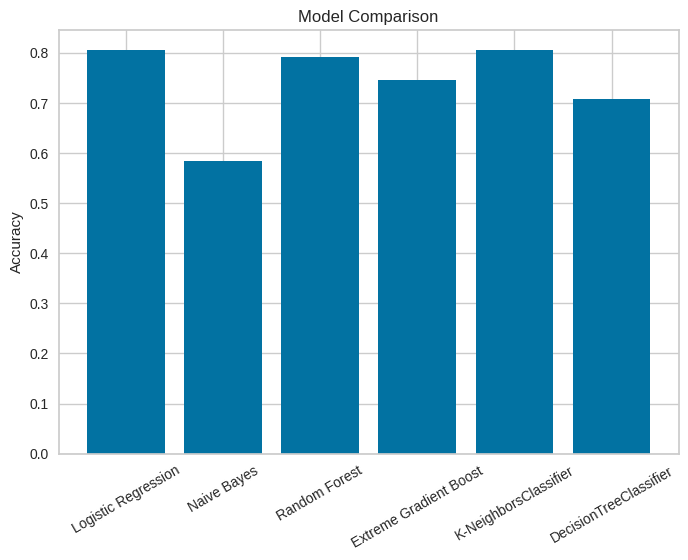

In [ ]:
# Defining alternative models

models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=20, random_state=12, max_depth=5),
    'Extreme Gradient Boost': XGBClassifier(
        learning_rate=0.01,
        n_estimators=25,
        max_depth=15,
        gamma=0.6,
        subsample=0.52,
        colsample_bytree=0.6,
        seed=27,
        reg_lambda=2,
        booster='dart',
        colsample_bylevel=0.6,
        colsample_bynode=0.5
    ),
    'K-NeighborsClassifier': KNeighborsClassifier(n_neighbors=10),
    'DecisionTreeClassifier': DecisionTreeClassifier(
        criterion='entropy',
        random_state=0,
        max_depth=6
    )
}

# Store results
results = {'Logistic Regression': lr_acc}

# Train, evaluate, and print metrics
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"\n--- {name} ---")
    print(f"\nAccuracy: {acc*100:.2f}%\n")
    print(classification_report(y_test, preds))

# Visualization
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

## 6. Neural Network Model (Deep Learning)
### Requirement: Train deep learning model / Improved accuracy achieved

We implement a multi-layer Neural Network using PyTorch to see if Deep Learning can extract deeper patterns from the health features.

### Architecture Details:

- **ReLU Activation**: Used in hidden layers to introduce non-linearity, allowing the model to learn complex heart disease patterns.

- **Dropout Layer**: A regularization technique where 40% of neurons are randomly "turned off" during training. This prevents Overfitting, ensuring the model generalizes to new patients rather than just memorizing the training set.

- **Sigmoid Output**: Transforms the final score into a probability between 0 and 1, where 1 represents a "Healthy" classification.

In [ ]:
# Converting data to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train_processed)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

class HeartDiseaseNN(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialization
nn_model = HeartDiseaseNN(X_train_processed.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.005, weight_decay=1e-4)

# Training loop
nn_model.train()
for epoch in range(100):
    optimizer.zero_grad()
    outputs = nn_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

# Evaluation
nn_model.eval()
with torch.no_grad():
    nn_probs = nn_model(X_test_tensor).numpy()
    nn_preds = (nn_probs >= 0.5).astype(int)
    nn_acc = accuracy_score(y_test, nn_preds)

results['Neural Network'] = nn_acc

print(f"Neural Network Final Accuracy: {nn_acc*100:.2f}%")

Neural Network Final Accuracy: 87.90%


## 7. Final Evaluation & Results
### Requirement: Model training/Accuracy acceptable

Finally, we visualize the performance to validate the model's reliability:

- **Confusion Matrix**: A visual breakdown showing exactly how many True Positives (correctly identified disease) and False Positives (healthy patients misidentified as diseased) the model produced.

- **ROC-AUC Curve**: Measures the model's ability to distinguish between classes. An AUC closer to 1.0 indicates a superior diagnostic tool.

- **Classification Report**: Provides Precision and Recall, which are vital in medicine where "missing" a sick patient (False Negative) is much more dangerous than a False Positive.

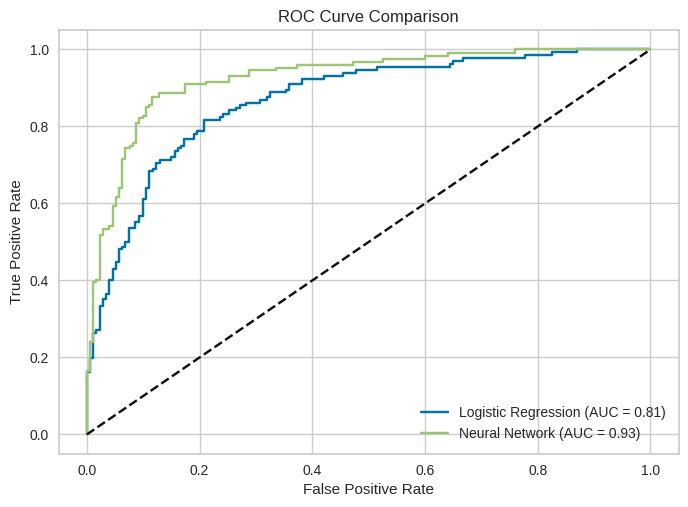

Final Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       526
           1       0.87      0.89      0.88       499

    accuracy                           0.88      1025
   macro avg       0.88      0.88      0.88      1025
weighted avg       0.88      0.88      0.88      1025



In [1008]:
# Final ROC Plotting logic for comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_processed)[:,1])
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_preds):.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {roc_auc_score(y_test, nn_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print("Final Report:")
print(classification_report(y_test, nn_preds))

In [1009]:
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(nn_model, 'nn_model.joblib')
joblib.dump(lr_model, 'lr_model.joblib')

['lr_model.joblib']